# 1.0 — Graph Exploration Notebook
**Project**: Optimizing Delivery ETAs with Graph-Based Network Intelligence  
**Phase**: 1 — Graph Construction & Data Pipeline  
**Purpose**: Interactive exploration and sanity-checks for `data_pipeline.py` and `graph_builder.py` outputs.

---
### Notebook Map
| Cell | What it does |
|---|---|
| 1 | Setup & imports |
| 2 | Run full data pipeline |
| 3 | Exploratory Data Analysis on cleaned trips |
| 4 | Delay ratio distribution analysis |
| 5 | Build & summarise the graph |
| 6 | Degree distribution |
| 7 | FTL vs Carting corridor comparison |
| 8 | Time-of-day delay heatmap |

In [1]:
# ── Cell 1: Setup ────────────────────────────────────────────────────────────
import sys, os
sys.path.insert(0, os.path.abspath('../src'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import networkx as nx
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

from data_pipeline import run_pipeline
from graph_builder import build_full_network, get_tod_subgraph

print('Setup complete ✓')

Setup complete ✓


In [2]:
# ── Cell 2: Run Data Pipeline ────────────────────────────────────────────────
# Expects delhivery_data.csv placed in data/raw/
pipeline_output = run_pipeline(filename='delhivery_data.csv')

df        = pipeline_output['cleaned']     # Row-level enriched trips
corridors = pipeline_output['corridors']   # Corridor-level aggregated (graph edges)
tod_df    = pipeline_output['tod']         # Time-of-day stratified corridors

print(f'Clean trips     : {len(df):,}')
print(f'Unique corridors: {len(corridors):,}')
print(f'TOD records     : {len(tod_df):,}')

00:01:03 | INFO | ============================================================
00:01:03 | INFO |   PHASE 1 — DATA PIPELINE STARTING
00:01:03 | INFO | ============================================================
00:01:03 | INFO | Loading raw data from D:\summer projects\delhivery-graph-intelligence\data\raw\delhivery_data.csv …
00:01:04 | INFO | Raw shape: 144867 rows × 24 columns
00:01:04 | INFO | Schema validation passed ✓
00:01:04 | WARNING | Column 'cutoff_timestamp': 3429 values could not be parsed → NaT
00:01:04 | INFO | Timestamp parsing complete; time_of_day buckets created ✓
00:01:04 | INFO | Dropping 0 rows with null actual_time or osrm_time.
00:01:04 | INFO | Dropping 0 rows with non-positive time values.
00:01:04 | INFO | Dropping 118499 duplicate segment rows.
00:01:05 | INFO | Cleaned shape: 26368 rows × 28 columns
00:01:05 | INFO | Delay features engineered. Avg segment delay ratio: 2.207 | SLA breach rate: 86.6%
00:01:05 | INFO | Segments sorted chronologically within ea

Clean trips     : 26,368
Unique corridors: 2,806
TOD records     : 4,079


In [3]:
# ── Cell 3: EDA on Cleaned Trips ─────────────────────────────────────────────
print('=== Dataset Overview ===')
print(df.dtypes.to_string())
print('\n=== Null Counts ===')
print(df.isnull().sum()[df.isnull().sum() > 0].to_string())
print('\n=== Route Type Distribution ===')
print(df['route_type'].value_counts())
print('\n=== Time-of-Day Distribution ===')
print(df['time_of_day'].value_counts())

=== Dataset Overview ===
data                                      object
trip_creation_time                datetime64[ns]
route_schedule_uuid                       object
route_type                                object
trip_uuid                                 object
source_center                             object
source_name                               object
destination_center                        object
destination_name                          object
od_start_time                     datetime64[ns]
od_end_time                       datetime64[ns]
start_scan_to_end_scan                   float64
is_cutoff                                   bool
cutoff_factor                              int64
cutoff_timestamp                  datetime64[ns]
actual_distance_to_destination           float64
actual_time                              float64
osrm_time                                float64
osrm_distance                            float64
factor                                   flo

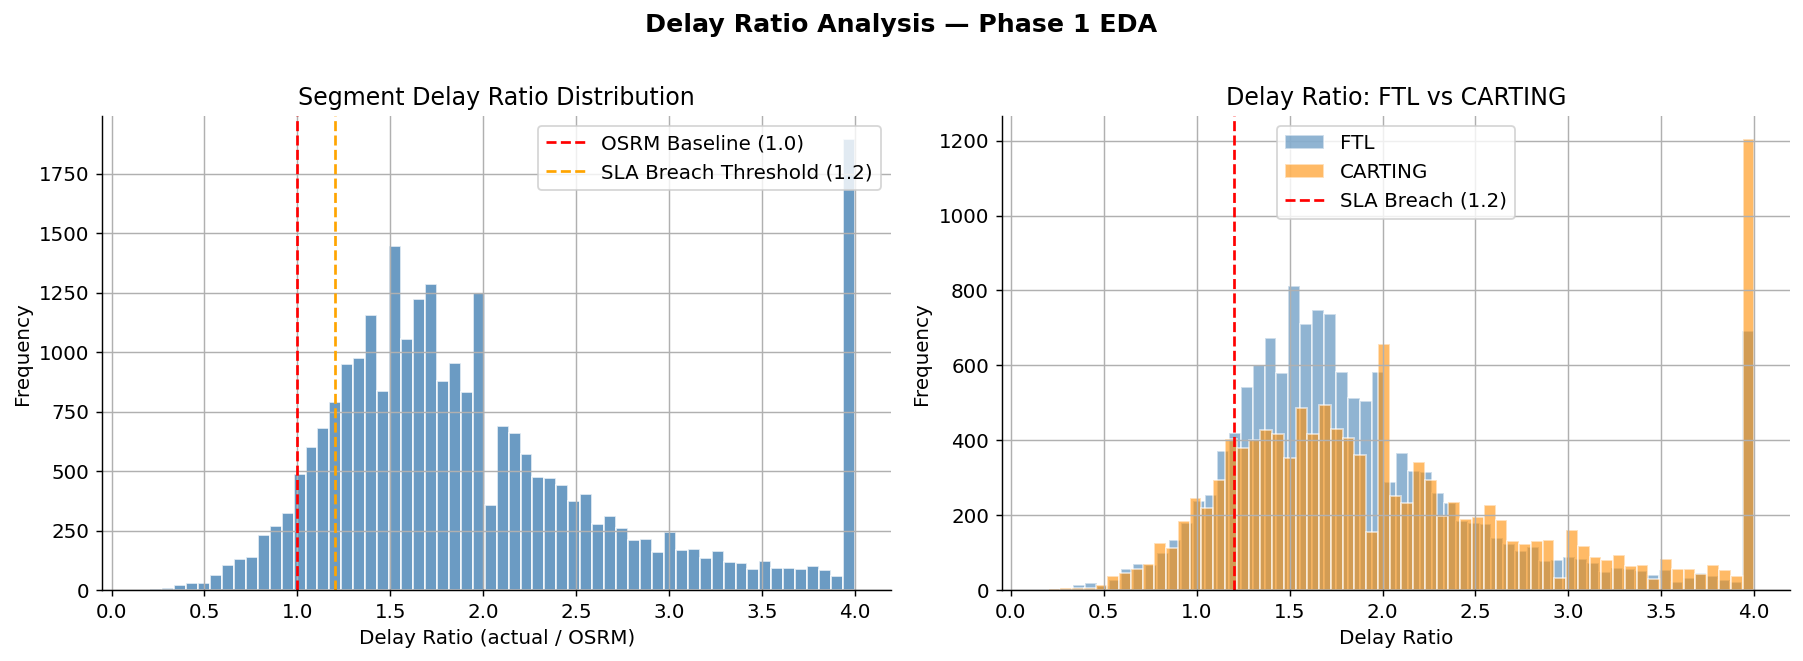


Overall SLA breach rate : 86.6%
FTL SLA breach rate     : 87.5%
CARTING SLA breach rate : 85.6%


In [4]:
# ── Cell 4: Delay Ratio Distribution ─────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall distribution
ax = axes[0]
df['segment_delay_ratio'].clip(0, 4).hist(bins=60, ax=ax, color='steelblue', alpha=0.8, edgecolor='white')
ax.axvline(1.0, color='red',    linestyle='--', linewidth=1.5, label='OSRM Baseline (1.0)')
ax.axvline(1.2, color='orange', linestyle='--', linewidth=1.5, label='SLA Breach Threshold (1.2)')
ax.set_title('Segment Delay Ratio Distribution')
ax.set_xlabel('Delay Ratio (actual / OSRM)')
ax.set_ylabel('Frequency')
ax.legend()

# By route type
ax = axes[1]
for rt, color in [('FTL', 'steelblue'), ('CARTING', 'darkorange')]:
    subset = df[df['route_type'] == rt]['segment_delay_ratio'].clip(0, 4)
    subset.hist(bins=60, ax=ax, color=color, alpha=0.6, label=rt, edgecolor='white')
ax.axvline(1.2, color='red', linestyle='--', linewidth=1.5, label='SLA Breach (1.2)')
ax.set_title('Delay Ratio: FTL vs CARTING')
ax.set_xlabel('Delay Ratio')
ax.set_ylabel('Frequency')
ax.legend()

plt.suptitle('Delay Ratio Analysis — Phase 1 EDA', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../outputs/visualizations/delay_ratio_distribution.png', bbox_inches='tight')
plt.show()

print(f"\nOverall SLA breach rate : {df['is_sla_breach'].mean()*100:.1f}%")
print(f"FTL SLA breach rate     : {df[df['route_type']=='FTL']['is_sla_breach'].mean()*100:.1f}%")
print(f"CARTING SLA breach rate : {df[df['route_type']=='CARTING']['is_sla_breach'].mean()*100:.1f}%")

In [5]:
# ── Cell 5: Build & Summarise the Graph ──────────────────────────────────────
net = build_full_network(corridor_df=corridors, tod_df=tod_df, save=True)

G         = net['graph']
summary   = net['summary']
ftl_G     = net['ftl_subgraph']
carting_G = net['carting_subgraph']

display(summary)

00:01:07 | INFO | ============================================================
00:01:07 | INFO |   PHASE 1 — GRAPH CONSTRUCTION STARTING
00:01:07 | INFO | ============================================================
00:01:07 | INFO | Nodes added: 1657 facilities
00:01:07 | INFO | Graph built: 1657 nodes | 2806 directed edges | 0 isolated nodes
00:01:07 | INFO | Node feature enrichment complete ✓
00:01:07 | INFO | Subgraph [FTL]: 1657 nodes | 1735 edges
00:01:07 | INFO | Subgraph [CARTING]: 1657 nodes | 1071 edges



  DELHIVERY NETWORK — GRAPH SUMMARY
                          Metric       Value
        Total Nodes (Facilities) 1657.000000
Total Directed Edges (Corridors) 2806.000000
                   Graph Density    0.001023
   Avg Edge Weight (Delay Ratio)    2.200800
Max Edge Weight (Worst Corridor)   31.200000
 Min Edge Weight (Best Corridor)    0.353000
                       FTL Edges 1735.000000
                   CARTING Edges 1071.000000
     Weakly Connected Components   64.000000
   Strongly Connected Components  545.000000



00:01:07 | INFO | Graph saved → D:\summer projects\delhivery-graph-intelligence\outputs\visualizations\delhivery_graph.graphml
00:01:07 | INFO | Graph pickled → D:\summer projects\delhivery-graph-intelligence\outputs\models\delhivery_graph.pkl
00:01:07 | INFO | Edge list saved → data/processed/graph_edge_list.csv
00:01:07 | INFO | ============================================================
00:01:07 | INFO |   PHASE 1 — GRAPH CONSTRUCTION COMPLETE
00:01:07 | INFO | ============================================================


,Metric,Value
0,Total Nodes (Facilities),1657.000000
1,Total Directed Edges (Corridors),2806.000000
2,Graph Density,0.001023
3,Avg Edge Weight (Delay Ratio),2.200800
4,Max Edge Weight (Worst Corridor),31.200000
5,Min Edge Weight (Best Corridor),0.353000
6,FTL Edges,1735.000000
7,CARTING Edges,1071.000000
8,Weakly Connected Components,64.000000
9,Strongly Connected Components,545.000000


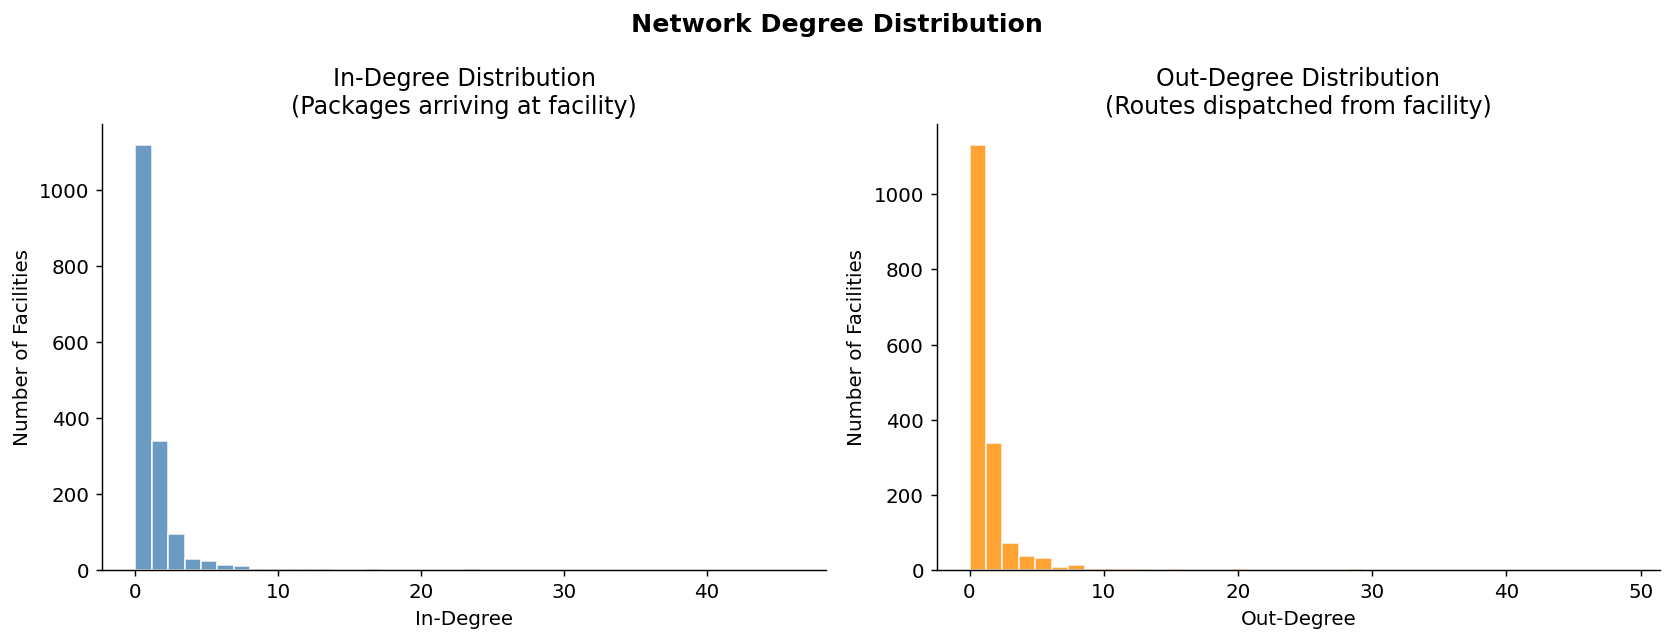

Top 5 highest in-degree hubs (busiest receiving facilities):
  GURGAON_BILASPUR_HB (HARYANA)            in-degree: 46
  BANGALORE_NELMNGLA_H (KARNATAKA)         in-degree: 37
  CHANDIGARH_MEHMDPUR_H (PUNJAB)           in-degree: 33
  HYDERABAD_SHAMSHBD_H (TELANGANA)         in-degree: 31
  BHIWANDI_MANKOLI_HB (MAHARASHTRA)        in-degree: 29


In [6]:
# ── Cell 6: Degree Distribution ──────────────────────────────────────────────
in_degrees  = [d for _, d in G.in_degree()]
out_degrees = [d for _, d in G.out_degree()]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(in_degrees,  bins=40, color='steelblue',  alpha=0.8, edgecolor='white')
axes[0].set_title('In-Degree Distribution\n(Packages arriving at facility)')
axes[0].set_xlabel('In-Degree')
axes[0].set_ylabel('Number of Facilities')

axes[1].hist(out_degrees, bins=40, color='darkorange', alpha=0.8, edgecolor='white')
axes[1].set_title('Out-Degree Distribution\n(Routes dispatched from facility)')
axes[1].set_xlabel('Out-Degree')
axes[1].set_ylabel('Number of Facilities')

plt.suptitle('Network Degree Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/visualizations/degree_distribution.png', bbox_inches='tight')
plt.show()

print(f'Top 5 highest in-degree hubs (busiest receiving facilities):')
top_in = sorted(G.in_degree(), key=lambda x: x[1], reverse=True)[:5]
for node, deg in top_in:
    print(f"  {G.nodes[node].get('name', node):<40} in-degree: {deg}")

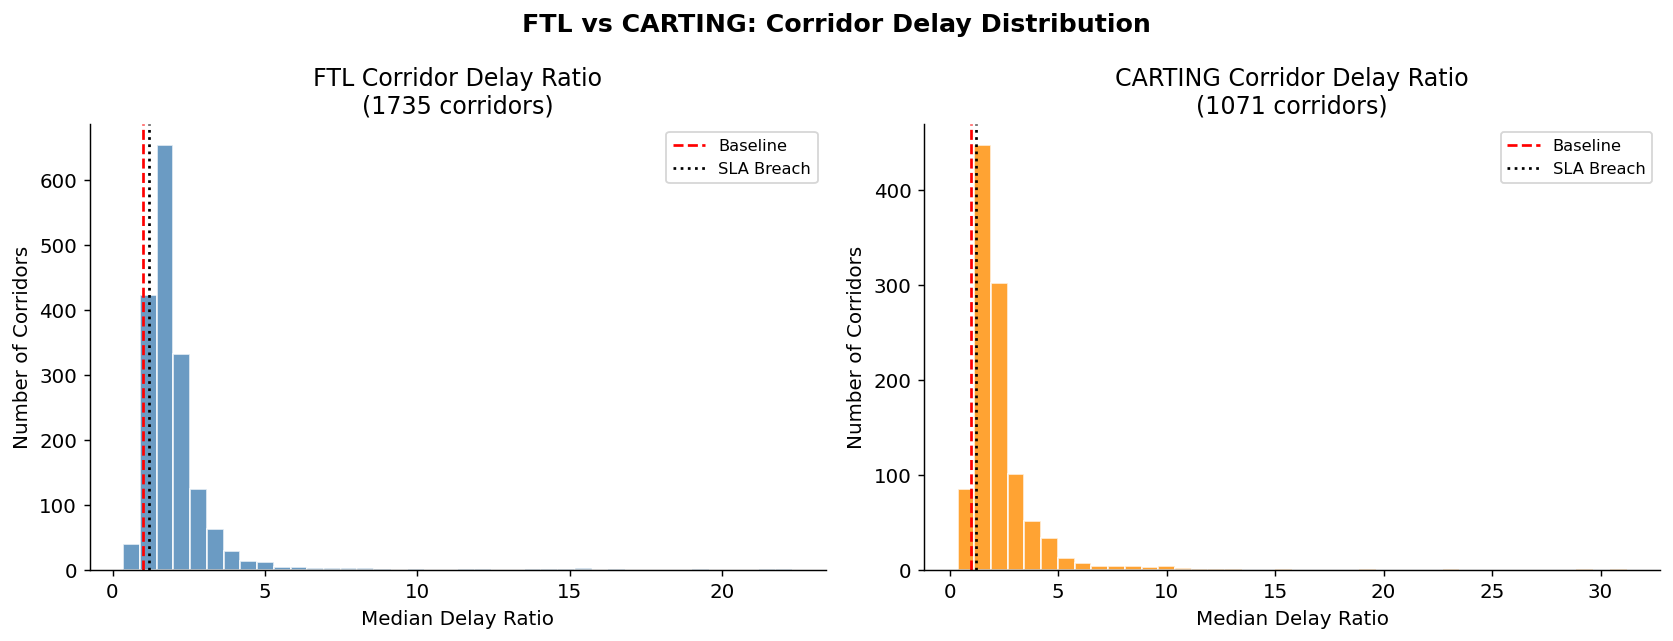

In [7]:
# ── Cell 7: FTL vs CARTING Corridor Comparison ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, subg, label, color in [
    (axes[0], ftl_G,     'FTL',     'steelblue'),
    (axes[1], carting_G, 'CARTING', 'darkorange'),
]:
    weights = [d.get('weight', np.nan) for _, _, d in subg.edges(data=True)]
    weights = [w for w in weights if not np.isnan(w)]
    ax.hist(weights, bins=40, color=color, alpha=0.8, edgecolor='white')
    ax.axvline(1.0, color='red',    linestyle='--', linewidth=1.5, label='Baseline')
    ax.axvline(1.2, color='black',  linestyle=':',  linewidth=1.5, label='SLA Breach')
    ax.set_title(f'{label} Corridor Delay Ratio\n({subg.number_of_edges()} corridors)')
    ax.set_xlabel('Median Delay Ratio')
    ax.set_ylabel('Number of Corridors')
    ax.legend(fontsize=9)

plt.suptitle('FTL vs CARTING: Corridor Delay Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/visualizations/ftl_vs_carting_delay.png', bbox_inches='tight')
plt.show()

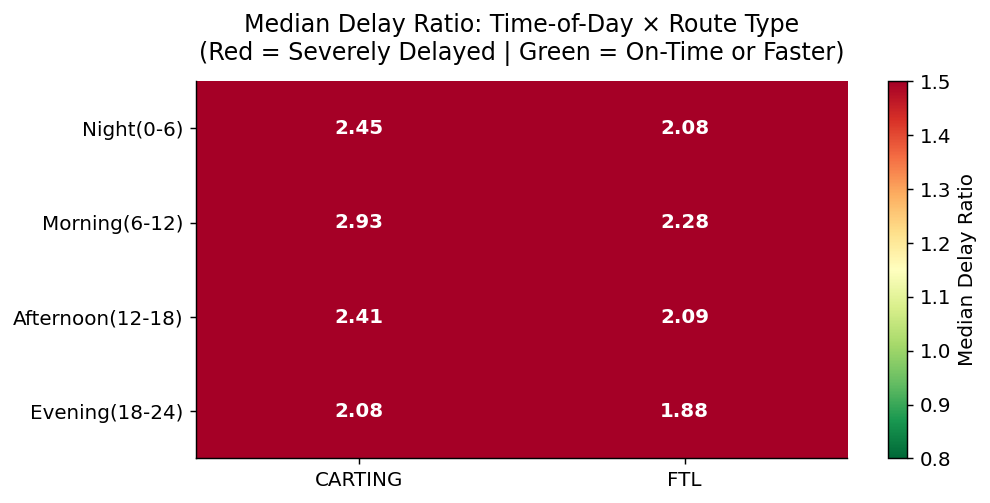


Phase 1 exploration complete. All visualizations saved to outputs/visualizations/


In [8]:
# ── Cell 8: Time-of-Day Delay Heatmap ────────────────────────────────────────
tod_pivot = (
    tod_df.groupby(['time_of_day', 'route_type'])['tod_median_delay']
    .mean()
    .unstack('route_type')
    .reindex(['Night(0-6)', 'Morning(6-12)', 'Afternoon(12-18)', 'Evening(18-24)'])
)

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(tod_pivot.values, cmap='RdYlGn_r', aspect='auto', vmin=0.8, vmax=1.5)
plt.colorbar(im, ax=ax, label='Median Delay Ratio')
ax.set_xticks(range(len(tod_pivot.columns)))
ax.set_xticklabels(tod_pivot.columns)
ax.set_yticks(range(len(tod_pivot.index)))
ax.set_yticklabels(tod_pivot.index)

for i in range(len(tod_pivot.index)):
    for j in range(len(tod_pivot.columns)):
        val = tod_pivot.values[i, j]
        ax.text(j, i, f'{val:.2f}' if not np.isnan(val) else 'N/A',
                ha='center', va='center', fontsize=11, fontweight='bold',
                color='white' if val > 1.3 or val < 0.9 else 'black')

ax.set_title('Median Delay Ratio: Time-of-Day × Route Type\n(Red = Severely Delayed | Green = On-Time or Faster)', pad=12)
plt.tight_layout()
plt.savefig('../outputs/visualizations/tod_delay_heatmap.png', bbox_inches='tight')
plt.show()

print('\nPhase 1 exploration complete. All visualizations saved to outputs/visualizations/')